<a href="https://colab.research.google.com/github/pythonwithzeeshan/Research_paper/blob/DrugDiscovery/Drug.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.19.0
GPU Available: False
               DRUG DISCOVERY & MOLECULAR PROPERTY PREDICTION

[1] Generating dataset...
Generating molecular features...
Generating fingerprints...
Generating properties...

Dataset: 2000 molecules, 270 features
Descriptors: 14
Fingerprints: 256

[2] Descriptor Statistics:
       MolWeight     LogP      HBD      HBA     TPSA  RotBonds  ArRings  \
count    2000.00  2000.00  2000.00  2000.00  2000.00   2000.00  2000.00   
mean      405.80     2.44     1.96     4.07    90.60      4.99     1.47   
std       179.76     1.48     1.38     2.10    52.25      2.20     1.23   
min        46.63    -2.27     0.00     0.00     5.44      0.00     0.00   
25%       275.69     1.46     1.00     3.00    52.64      3.00     1.00   
50%       380.91     2.47     2.00     4.00    80.36      5.00     1.00   
75%       501.18     3.44     3.00     5.00   118.14      6.00     2.00   
max      1545.95     7.36     8.00    13.00   390.04     15.00     7.00   

 

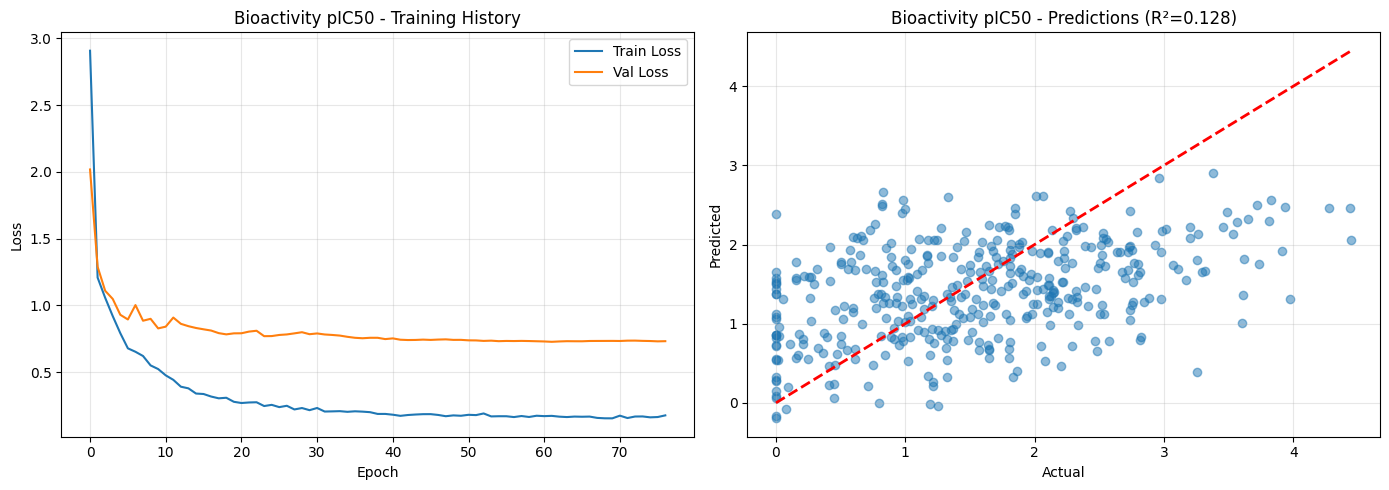


TASK: Solubility logS (regression)
Train: 1280, Val: 320, Test: 400

Training Random Forest...
RF: RMSE=0.6080, R²=0.9246

Training Deep Neural Network...
Training completed in 93 epochs
DNN: RMSE=0.9122, R²=0.8302, MAE=0.7214


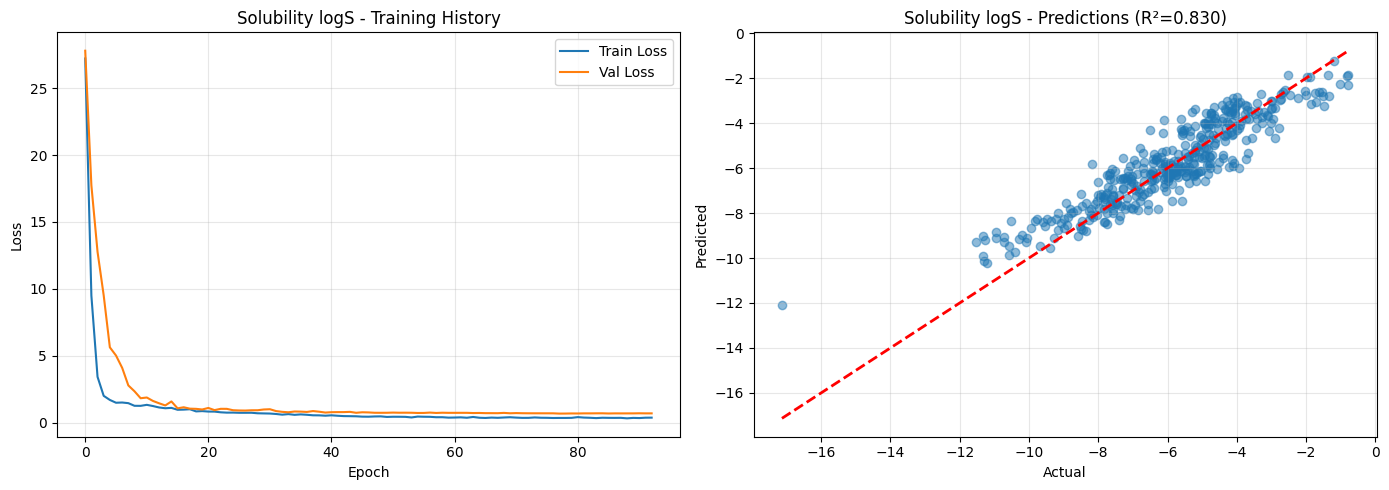


TASK: Permeability Caco2 (regression)
Train: 1280, Val: 320, Test: 400

Training Random Forest...
RF: RMSE=0.5673, R²=0.7545

Training Deep Neural Network...
Training completed in 37 epochs
DNN: RMSE=0.6741, R²=0.6533, MAE=0.5466


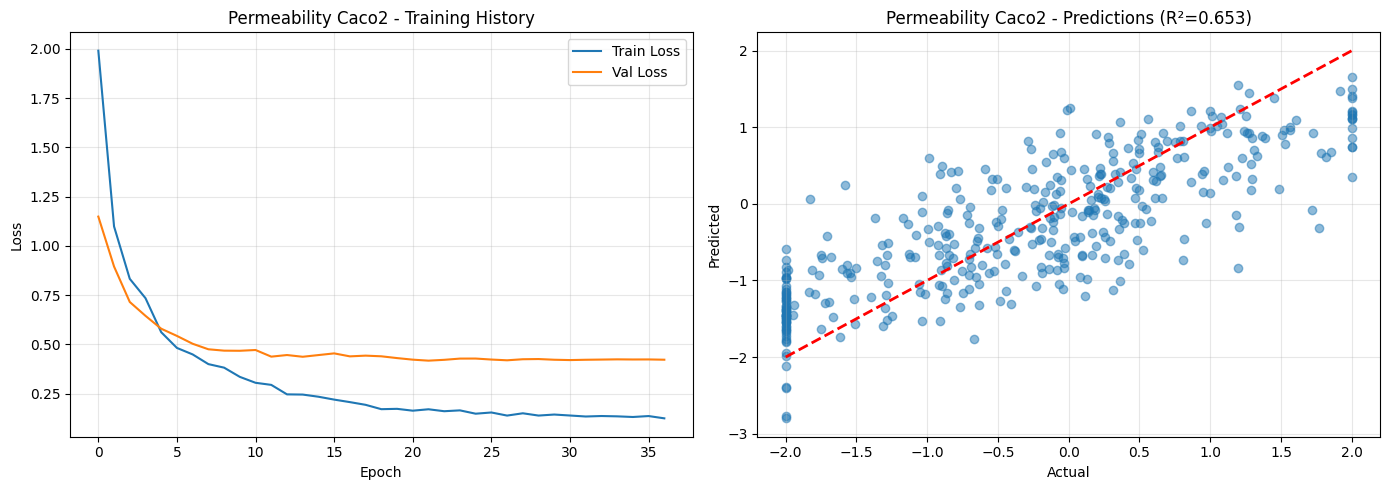


TASK: Toxicity (classification)
Train: 1280, Val: 320, Test: 400

Training Random Forest...
RF: Accuracy=0.7550

Training Deep Neural Network...
Training completed in 17 epochs
DNN: Accuracy=0.7625, AUC=0.8528


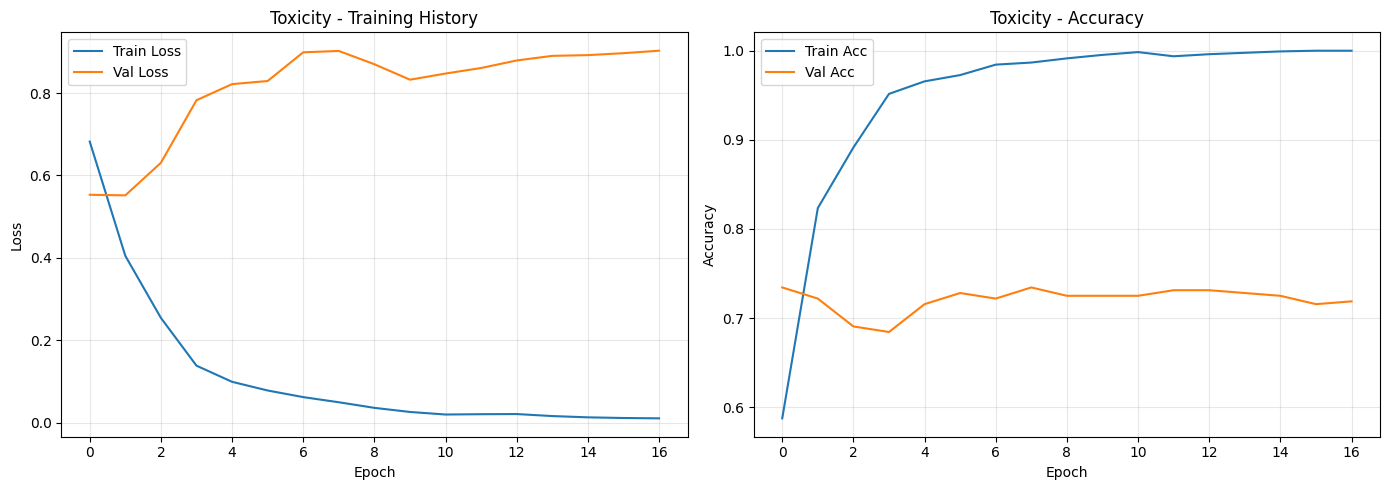


TASK: DrugLikeness (classification)
Train: 1280, Val: 320, Test: 400

Training Random Forest...
RF: Accuracy=0.9550

Training Deep Neural Network...
Training completed in 17 epochs
DNN: Accuracy=0.8800, AUC=0.9419


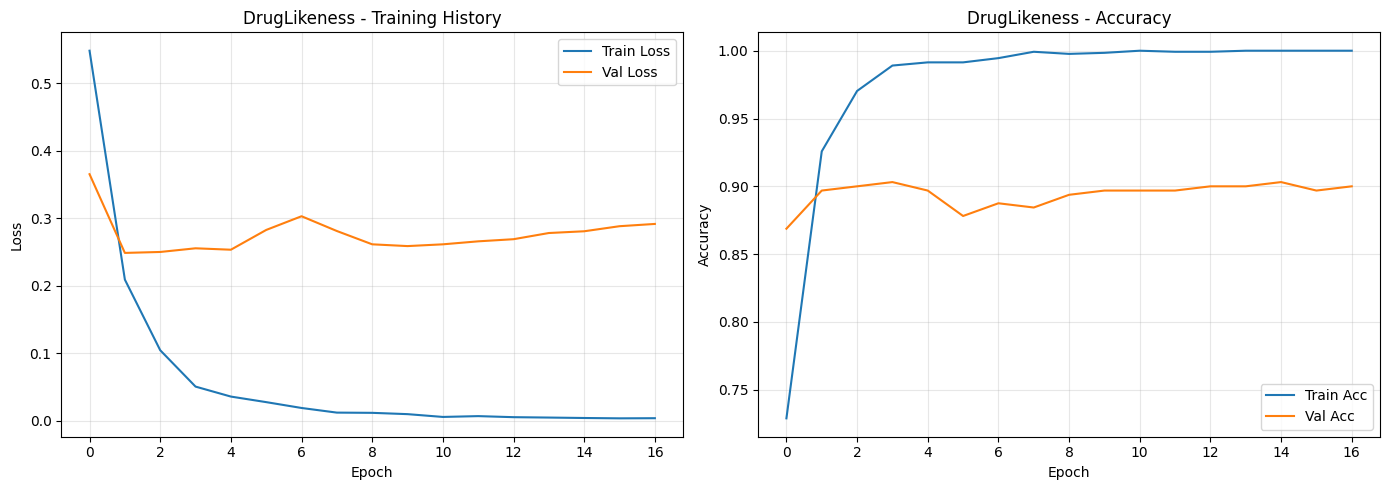


FINAL SUMMARY
                        RMSE        R²       MAE  Accuracy   AUC-ROC
Bioactivity pIC50   0.923099  0.127940  0.746387       NaN       NaN
Solubility logS     0.912192  0.830212  0.721369       NaN       NaN
Permeability Caco2  0.674079  0.653292  0.546570       NaN       NaN
Toxicity                 NaN       NaN       NaN    0.7625  0.852823
DrugLikeness             NaN       NaN       NaN    0.8800  0.941911

✓ Analysis Complete!


In [10]:
"""
Drug Discovery and Molecular Property Prediction
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

# ===================================================================
# PART 1: Generate Dataset
# ===================================================================

def generate_molecular_dataset(n_samples=2000):
    """Generate synthetic molecular features and properties"""

    print("Generating molecular features...")

    # Generate 14 molecular descriptors
    data = {
        'MolWeight': np.random.gamma(5, 80, n_samples),
        'LogP': np.random.normal(2.5, 1.5, n_samples),
        'HBD': np.random.poisson(2, n_samples),
        'HBA': np.random.poisson(4, n_samples),
        'TPSA': np.random.gamma(3, 30, n_samples),
        'RotBonds': np.random.poisson(5, n_samples),
        'ArRings': np.random.poisson(1.5, n_samples),
        'AlRings': np.random.poisson(1, n_samples),
        'FracCSP3': np.random.beta(2, 2, n_samples),
        'MolMR': np.random.gamma(4, 25, n_samples),
        'Hetero': np.random.poisson(3, n_samples),
        'SatRings': np.random.poisson(0.8, n_samples),
    }

    features_df = pd.DataFrame(data)

    # Lipinski compliance
    features_df['Lipinski'] = (
        (features_df['MolWeight'] <= 500) &
        (features_df['LogP'] <= 5) &
        (features_df['HBD'] <= 5) &
        (features_df['HBA'] <= 10)
    ).astype(int)

    features_df['LipViol'] = (
        (features_df['MolWeight'] > 500).astype(int) +
        (features_df['LogP'] > 5).astype(int) +
        (features_df['HBD'] > 5).astype(int) +
        (features_df['HBA'] > 10).astype(int)
    )

    print("Generating fingerprints...")
    fingerprints = np.random.binomial(1, 0.3, (n_samples, 256))

    print("Generating properties...")

    # Target properties
    bioactivity = (
        0.3 * features_df['LogP'] +
        0.2 * (500 - features_df['MolWeight']) / 100 +
        0.15 * features_df['HBA'] +
        np.random.normal(0, 0.8, n_samples)
    )
    bioactivity = np.clip(bioactivity, 0, 10)

    solubility = (
        -0.01 * features_df['MolWeight'] -
        0.7 * features_df['LogP'] +
        0.05 * features_df['HBD'] +
        np.random.normal(0, 0.5, n_samples)
    )

    permeability = (
        0.5 * features_df['LogP'] -
        0.02 * features_df['TPSA'] +
        0.3 * features_df['Lipinski'] +
        np.random.normal(0, 0.6, n_samples)
    )
    permeability = np.clip(permeability, -2, 2)

    toxicity_score = (
        0.002 * features_df['MolWeight'] +
        0.3 * features_df['LogP'] +
        0.1 * features_df['LipViol'] +
        np.random.normal(0, 0.4, n_samples)
    )
    toxicity = (toxicity_score > 1.2).astype(int)

    druglikeness = (
        (features_df['Lipinski'] == 1) &
        (features_df['TPSA'] <= 140) &
        (features_df['LogP'] >= -0.4) &
        (features_df['LogP'] <= 5.6)
    ).astype(int)

    # Combine features
    X = np.hstack([features_df.values, fingerprints])

    properties = {
        'Bioactivity': bioactivity,
        'Solubility': solubility,
        'Permeability': permeability,
        'Toxicity': toxicity,
        'DrugLikeness': druglikeness
    }

    return X, properties, features_df

# ===================================================================
# PART 2: Build Models
# ===================================================================

def create_dnn_model(input_dim, task_type='regression'):
    """Create DNN model - simple approach without custom names"""

    # Clear any existing sessions
    tf.keras.backend.clear_session()

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(input_dim,)))
    model.add(keras.layers.Dense(1024, activation=None))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Activation('relu'))
    model.add(keras.layers.Dropout(0.3))

    model.add(keras.layers.Dense(512, activation=None))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Activation('relu'))
    model.add(keras.layers.Dropout(0.3))

    model.add(keras.layers.Dense(256, activation=None))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Activation('relu'))
    model.add(keras.layers.Dropout(0.2))

    model.add(keras.layers.Dense(128, activation=None))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Activation('relu'))
    model.add(keras.layers.Dropout(0.2))

    if task_type == 'classification':
        model.add(keras.layers.Dense(1, activation='sigmoid'))
        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy', keras.metrics.AUC()]
        )
    else:
        model.add(keras.layers.Dense(1, activation='linear'))
        model.compile(
            optimizer='adam',
            loss='mse',
            metrics=['mae']
        )

    return model

# ===================================================================
# PART 3: Training Function
# ===================================================================

def train_and_evaluate(X, y, task_name, task_type):
    """Train and evaluate models"""

    print(f"\n{'='*80}")
    print(f"TASK: {task_name} ({task_type})")
    print(f"{'='*80}")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42,
        stratify=y if task_type == 'classification' else None
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42,
        stratify=y_train if task_type == 'classification' else None
    )

    print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

    # Scale features
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    # Random Forest baseline
    print("\nTraining Random Forest...")
    if task_type == 'regression':
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    else:
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)

    if task_type == 'regression':
        rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
        rf_r2 = r2_score(y_test, rf_pred)
        print(f"RF: RMSE={rf_rmse:.4f}, R²={rf_r2:.4f}")
    else:
        rf_acc = accuracy_score(y_test, rf_pred)
        print(f"RF: Accuracy={rf_acc:.4f}")

    # Deep Neural Network
    print("\nTraining Deep Neural Network...")
    model = create_dnn_model(X.shape[1], task_type)

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )

    history = model.fit(
        X_train_s, y_train,
        validation_data=(X_val_s, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    print(f"Training completed in {len(history.history['loss'])} epochs")

    # Evaluate
    y_pred = model.predict(X_test_s, verbose=0).flatten()

    if task_type == 'classification':
        y_pred_class = (y_pred > 0.5).astype(int)
        acc = accuracy_score(y_test, y_pred_class)
        try:
            auc = roc_auc_score(y_test, y_pred)
        except:
            auc = 0.5
        print(f"DNN: Accuracy={acc:.4f}, AUC={auc:.4f}")
        metrics = {'Accuracy': acc, 'AUC-ROC': auc}
    else:
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mae = np.mean(np.abs(y_test - y_pred))
        print(f"DNN: RMSE={rmse:.4f}, R²={r2:.4f}, MAE={mae:.4f}")
        metrics = {'RMSE': rmse, 'R²': r2, 'MAE': mae}

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{task_name} - Training History')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if task_type == 'regression':
        axes[1].scatter(y_test, y_pred, alpha=0.5)
        axes[1].plot([y_test.min(), y_test.max()],
                     [y_test.min(), y_test.max()], 'r--', lw=2)
        axes[1].set_xlabel('Actual')
        axes[1].set_ylabel('Predicted')
        axes[1].set_title(f'{task_name} - Predictions (R²={r2:.3f})')
    else:
        if 'accuracy' in history.history:
            axes[1].plot(history.history['accuracy'], label='Train Acc')
            axes[1].plot(history.history['val_accuracy'], label='Val Acc')
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('Accuracy')
            axes[1].set_title(f'{task_name} - Accuracy')
            axes[1].legend()

    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return model, metrics, history

# ===================================================================
# PART 4: Main Pipeline
# ===================================================================

def main():
    """Main execution"""

    print("="*80)
    print(" "*15 + "DRUG DISCOVERY & MOLECULAR PROPERTY PREDICTION")
    print("="*80)

    # Generate dataset
    print("\n[1] Generating dataset...")
    X, properties, features_df = generate_molecular_dataset(n_samples=2000)

    print(f"\nDataset: {X.shape[0]} molecules, {X.shape[1]} features")
    print(f"Descriptors: {features_df.shape[1]}")
    print(f"Fingerprints: {X.shape[1] - features_df.shape[1]}")

    print("\n[2] Descriptor Statistics:")
    print(features_df.describe().round(2))

    # Define tasks
    tasks = [
        ('Bioactivity pIC50', 'regression', properties['Bioactivity']),
        ('Solubility logS', 'regression', properties['Solubility']),
        ('Permeability Caco2', 'regression', properties['Permeability']),
        ('Toxicity', 'classification', properties['Toxicity']),
        ('DrugLikeness', 'classification', properties['DrugLikeness'])
    ]

    results = {}

    # Train models
    print("\n[3] Training models...")
    for task_name, task_type, y in tasks:
        model, metrics, history = train_and_evaluate(X, y, task_name, task_type)
        results[task_name] = metrics

    # Summary
    print(f"\n{'='*80}")
    print("FINAL SUMMARY")
    print(f"{'='*80}")

    summary_df = pd.DataFrame(results).T
    print(summary_df.to_string())

    print("\n" + "="*80)
    print("✓ Analysis Complete!")
    print("="*80)

    return results, features_df

# Run
if __name__ == "__main__":
    results, features = main()